In [4]:
from google.colab import files
uploaded = files.upload()

Saving hour.csv to hour.csv


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


In [6]:
df_day = pd.read_csv("day.csv")
TARGET = "cnt"


In [7]:
df_day.drop(columns=["casual", "registered"], inplace=True)


In [8]:
df_day["dteday"] = pd.to_datetime(df_day["dteday"])

df_day["month"] = df_day["dteday"].dt.month
df_day["weekday"] = df_day["dteday"].dt.weekday
df_day["is_weekend"] = df_day["weekday"].isin([5, 6]).astype(int)


In [9]:
df_day["month_sin"] = np.sin(2 * np.pi * df_day["month"] / 12)
df_day["month_cos"] = np.cos(2 * np.pi * df_day["month"] / 12)


In [10]:
df_day["temp_humidity"] = df_day["temp"] * df_day["hum"]
df_day["temp_windspeed"] = df_day["temp"] * df_day["windspeed"]


In [11]:
df_day["is_working_day"] = ((df_day["workingday"] == 1) & (df_day["holiday"] == 0)).astype(int)


In [12]:
season_severity = {1: 1, 2: 0, 3: 1, 4: 2}
weather_severity = {1: 0, 2: 1, 3: 2, 4: 3}

df_day["severity"] = (
    df_day["season"].map(season_severity)
    + df_day["weathersit"].map(weather_severity)
)


In [13]:
df_day = df_day.sort_values("dteday")

df_day["cnt_lag_7"] = df_day["cnt"].shift(7)
df_day["cnt_diff_7"] = df_day["cnt"] - df_day["cnt_lag_7"]
df_day["rolling_mean_7"] = df_day["cnt"].rolling(7).mean()


In [14]:
scale_cols = ["temp", "hum", "windspeed", "temp_humidity", "temp_windspeed"]
scaler = StandardScaler()
df_day[scale_cols] = scaler.fit_transform(df_day[scale_cols])


In [15]:
df_day.drop(columns=["instant", "dteday", "weekday"], inplace=True)
df_day.dropna(inplace=True)


In [16]:
X_day = df_day.drop("cnt", axis=1)
y_day = df_day["cnt"]

print("DAY DATASET")
print("X shape:", X_day.shape)
print("y shape:", y_day.shape)


DAY DATASET
X shape: (724, 21)
y shape: (724,)


In [17]:
df_day.head()

,season,yr,mnth,holiday,workingday,weathersit,temp,atemp,hum,windspeed,...,is_weekend,month_sin,month_cos,temp_humidity,temp_windspeed,is_working_day,severity,cnt_lag_7,cnt_diff_7,rolling_mean_7
7,1,0,1,0,0,2,-1.806114,0.162254,-0.646807,0.985447,...,1,0.5,0.866025,-1.651271,-1.040337,0,2,985.0,-26.0,1341.000000
8,1,0,1,0,0,1,-1.951895,0.116175,-1.361096,2.214012,...,1,0.5,0.866025,-1.858484,-0.909560,0,1,801.0,21.0,1344.000000
9,1,0,1,0,1,1,-1.883561,0.150888,-1.018586,0.423279,...,0,0.5,0.866025,-1.765081,-1.264103,1,1,1349.0,-28.0,1340.000000
10,1,0,1,0,1,2,-1.783750,0.191464,0.410801,-0.882618,...,0,0.5,0.866025,-1.449227,-1.545786,1,2,1562.0,-299.0,1297.285714
11,1,0,1,0,1,1,-1.763873,0.160473,-0.199176,1.473833,...,0,0.5,0.866025,-1.540584,-0.854462,1,1,1600.0,-438.0,1234.714286


In [18]:
df_hour = pd.read_csv("hour.csv")
TARGET = "cnt"


In [19]:
df_hour.drop(columns=["casual", "registered"], inplace=True)


In [20]:
df_hour["dteday"] = pd.to_datetime(df_hour["dteday"])

df_hour["hour"] = df_hour["hr"]
df_hour["weekday"] = df_hour["dteday"].dt.weekday
df_hour["is_weekend"] = df_hour["weekday"].isin([5, 6]).astype(int)


In [21]:
df_hour["hour_sin"] = np.sin(2 * np.pi * df_hour["hour"] / 24)
df_hour["hour_cos"] = np.cos(2 * np.pi * df_hour["hour"] / 24)


In [22]:
def assign_time_block(hour):
    if 0 <= hour <= 5:
        return "late_night"
    elif 6 <= hour <= 10:
        return "start_day"
    elif 11 <= hour <= 16:
        return "mid_day"
    else:  # 17–23
        return "end_day"

df_hour["time_block"] = df_hour["hour"].apply(assign_time_block)



In [23]:
df_hour = pd.get_dummies(df_hour, columns=["time_block"], drop_first=True)


In [24]:
df_hour["temp_humidity"] = df_hour["temp"] * df_hour["hum"]
df_hour["temp_windspeed"] = df_hour["temp"] * df_hour["windspeed"]


In [25]:
df_hour["is_working_day"] = ((df_hour["workingday"] == 1) & (df_hour["holiday"] == 0)).astype(int)


In [26]:
df_hour["severity"] = (
    df_hour["season"].map(season_severity)
    + df_hour["weathersit"].map(weather_severity)
)


In [27]:
df_hour = df_hour.sort_values(["dteday", "hour"])

df_hour["cnt_lag_1"] = df_hour["cnt"].shift(1)
df_hour["cnt_lag_24"] = df_hour["cnt"].shift(24)
df_hour["cnt_diff_1"] = df_hour["cnt"] - df_hour["cnt_lag_1"]
df_hour["rolling_mean_24"] = df_hour["cnt"].rolling(24).mean()


In [28]:
df_hour[scale_cols] = scaler.fit_transform(df_hour[scale_cols])


In [29]:
df_hour.drop(columns=["instant", "dteday", "hr", "weekday"], inplace=True)
df_hour.dropna(inplace=True)


In [30]:
X_hour = df_hour.drop("cnt", axis=1)
y_hour = df_hour["cnt"]

print("\nHOUR DATASET")
print("X shape:", X_hour.shape)
print("y shape:", y_hour.shape)



HOUR DATASET
X shape: (17355, 25)
y shape: (17355,)


In [31]:
df_hour.head()

,season,yr,mnth,holiday,workingday,weathersit,temp,atemp,hum,windspeed,...,time_block_mid_day,time_block_start_day,temp_humidity,temp_windspeed,is_working_day,severity,cnt_lag_1,cnt_lag_24,cnt_diff_1,rolling_mean_24
24,1,0,1,0,0,2,-0.192091,0.4545,1.310209,0.886099,...,False,False,0.659541,0.602014,0,2,39.0,16.0,-22.0,41.083333
25,1,0,1,0,0,2,-0.295959,0.4394,1.621212,0.519896,...,False,False,0.720206,0.245596,0,2,17.0,40.0,0.0,40.125000
26,1,0,1,0,0,2,-0.399828,0.4242,1.932215,0.764304,...,False,False,0.764327,0.349460,0,2,17.0,32.0,-8.0,39.166667
27,1,0,1,0,0,2,-0.192091,0.4545,1.621212,0.031899,...,False,False,0.849810,-0.065107,0,2,9.0,13.0,-3.0,38.875000
28,1,0,1,0,0,2,-0.192091,0.4545,1.621212,0.031899,...,False,False,0.849810,-0.065107,0,2,6.0,1.0,-3.0,38.958333


In [32]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [39]:
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_hour,
    y_hour,
    test_size=0.2,
    shuffle=False
)


In [40]:
lr_hour = LinearRegression()
lr_hour.fit(Xh_train, yh_train)


LinearRegression()

In [41]:
yh_pred_lr = lr_hour.predict(Xh_test)

print("HOURLY – Linear Regression")
print("MAE :", mean_absolute_error(yh_test, yh_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(yh_test, yh_pred_lr)))
print("R²  :", r2_score(yh_test, yh_pred_lr))


HOURLY – Linear Regression
MAE : 1.9542484087968298e-13
RMSE: 2.5998323322489115e-13
R²  : 1.0


In [42]:
rf_hour = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_hour.fit(Xh_train, yh_train)


RandomForestRegressor(max_depth=15, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [43]:
yh_pred_rf = rf_hour.predict(Xh_test)

print("\nHOURLY – Random Forest")
print("MAE :", mean_absolute_error(yh_test, yh_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(yh_test, yh_pred_rf)))
print("R²  :", r2_score(yh_test, yh_pred_rf))



HOURLY – Random Forest
MAE : 7.737467225080059
RMSE: 22.426144365863298
R²  : 0.9896667335986816


In [44]:
feature_importance_hour = pd.Series(
    rf_hour.feature_importances_,
    index=X_hour.columns
).sort_values(ascending=False)

feature_importance_hour.head(10)


,0
cnt_lag_1,0.715208
cnt_diff_1,0.167791
cnt_lag_24,0.109357
hour,0.001320
hour_sin,0.000967
rolling_mean_24,0.000867
is_working_day,0.000623
workingday,0.000556
time_block_start_day,0.000551
atemp,0.000368


In [45]:
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_day,
    y_day,
    test_size=0.2,
    shuffle=False
)


In [46]:
lr_day = LinearRegression()
lr_day.fit(Xd_train, yd_train)


LinearRegression()

In [47]:
yd_pred_lr = lr_day.predict(Xd_test)

print("\nDAILY – Linear Regression")
print("MAE :", mean_absolute_error(yd_test, yd_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(yd_test, yd_pred_lr)))
print("R²  :", r2_score(yd_test, yd_pred_lr))



DAILY – Linear Regression
MAE : 1.818107350494568e-12
RMSE: 2.1925983020383564e-12
R²  : 1.0


In [48]:
rf_day = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_day.fit(Xd_train, yd_train)


RandomForestRegressor(max_depth=12, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [49]:
yd_pred_rf = rf_day.predict(Xd_test)

print("\nDAILY – Random Forest")
print("MAE :", mean_absolute_error(yd_test, yd_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(yd_test, yd_pred_rf)))
print("R²  :", r2_score(yd_test, yd_pred_rf))



DAILY – Random Forest
MAE : 506.1776213310905
RMSE: 717.1338999460805
R²  : 0.8543416743956209


In [50]:
feature_importance_day = pd.Series(
    rf_day.feature_importances_,
    index=X_day.columns
).sort_values(ascending=False)

feature_importance_day.head(10)


,0
rolling_mean_7,0.805039
cnt_diff_7,0.103001
cnt_lag_7,0.027297
atemp,0.013984
temp,0.009564
hum,0.009463
temp_humidity,0.006701
windspeed,0.004977
weathersit,0.004524
temp_windspeed,0.003518


In [51]:
yh_pred_lr = lr_hour.predict(Xh_test)
yh_pred_rf = rf_hour.predict(Xh_test)


In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("HOURLY – Linear Regression (TEST)")
print("MAE :", mean_absolute_error(yh_test, yh_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(yh_test, yh_pred_lr)))
print("R²  :", r2_score(yh_test, yh_pred_lr))

print("\nHOURLY – Random Forest (TEST)")
print("MAE :", mean_absolute_error(yh_test, yh_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(yh_test, yh_pred_rf)))
print("R²  :", r2_score(yh_test, yh_pred_rf))


HOURLY – Linear Regression (TEST)
MAE : 1.9542484087968298e-13
RMSE: 2.5998323322489115e-13
R²  : 1.0

HOURLY – Random Forest (TEST)
MAE : 7.737467225080059
RMSE: 22.426144365863298
R²  : 0.9896667335986816


In [53]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": yh_test.values[:10],
    "Predicted": yh_pred_rf[:10]
})

comparison




,Actual,Predicted
0,868,859.884167
1,814,825.564833
2,610,594.733182
3,448,453.317739
4,317,319.354608
5,224,224.730043
6,138,140.563416
7,58,57.702207
8,23,22.823824
9,6,6.180046


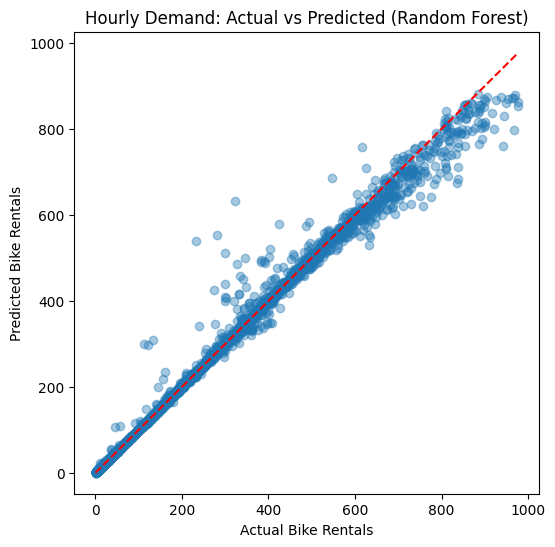

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(yh_test, yh_pred_rf, alpha=0.4)
plt.plot([yh_test.min(), yh_test.max()],
         [yh_test.min(), yh_test.max()],
         color="red", linestyle="--")
plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Hourly Demand: Actual vs Predicted (Random Forest)")
plt.show()


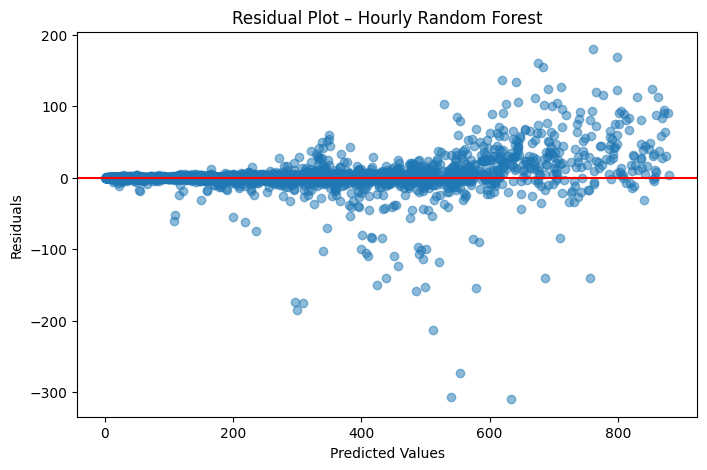

In [55]:
residuals_hour = yh_test - yh_pred_rf

plt.figure(figsize=(8,5))
plt.scatter(yh_pred_rf, residuals_hour, alpha=0.5)
plt.axhline(0, color="red")
plt.title("Residual Plot – Hourly Random Forest")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()


In [56]:
yd_pred_lr = lr_day.predict(Xd_test)
yd_pred_rf = rf_day.predict(Xd_test)


In [57]:
print("DAILY – Linear Regression (TEST)")
print("MAE :", mean_absolute_error(yd_test, yd_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(yd_test, yd_pred_lr)))
print("R²  :", r2_score(yd_test, yd_pred_lr))

print("\nDAILY – Random Forest (TEST)")
print("MAE :", mean_absolute_error(yd_test, yd_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(yd_test, yd_pred_rf)))
print("R²  :", r2_score(yd_test, yd_pred_rf))


DAILY – Linear Regression (TEST)
MAE : 1.818107350494568e-12
RMSE: 2.1925983020383564e-12
R²  : 1.0

DAILY – Random Forest (TEST)
MAE : 506.1776213310905
RMSE: 717.1338999460805
R²  : 0.8543416743956209


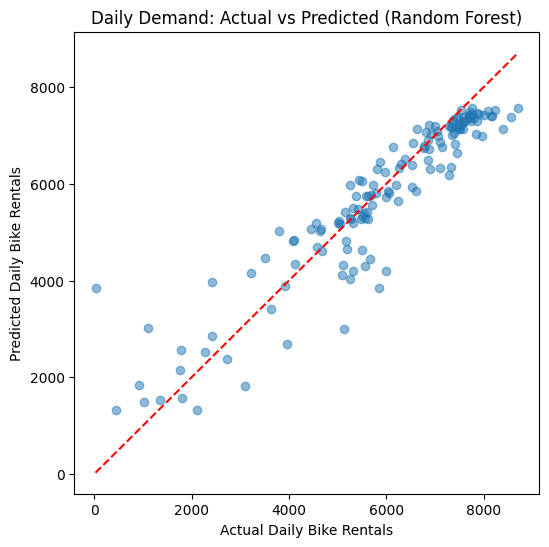

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(yd_test, yd_pred_rf, alpha=0.5)
plt.plot([yd_test.min(), yd_test.max()],
         [yd_test.min(), yd_test.max()],
         color="red", linestyle="--")
plt.xlabel("Actual Daily Bike Rentals")
plt.ylabel("Predicted Daily Bike Rentals")
plt.title("Daily Demand: Actual vs Predicted (Random Forest)")
plt.show()



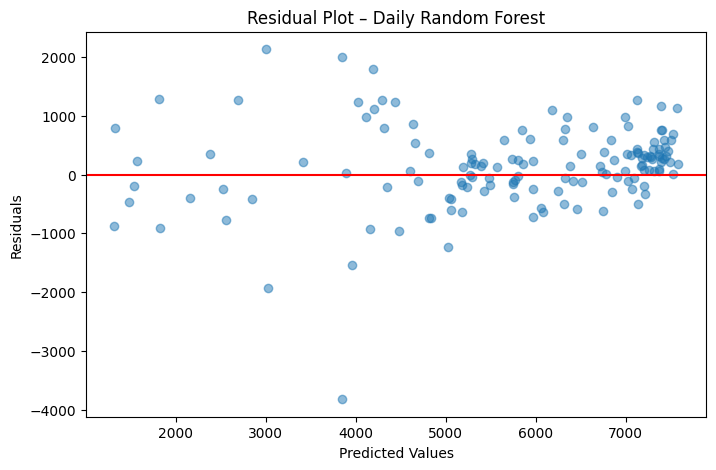

In [59]:
residuals_day = yd_test - yd_pred_rf

plt.figure(figsize=(8,5))
plt.scatter(yd_pred_rf, residuals_day, alpha=0.5)
plt.axhline(0, color="red")
plt.title("Residual Plot – Daily Random Forest")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()


In [60]:
hourly_accuracy = r2_score(yh_test, yh_pred_rf) * 100
daily_accuracy = r2_score(yd_test, yd_pred_rf) * 100

print(f"Hourly Prediction Accuracy: {hourly_accuracy:.2f}%")
print(f"Daily Prediction Accuracy: {daily_accuracy:.2f}%")


Hourly Prediction Accuracy: 98.97%
Daily Prediction Accuracy: 85.43%


In [61]:
def mape(y_true, y_pred):
    return (abs((y_true - y_pred) / y_true)).mean() * 100

hourly_mape = mape(yh_test, yh_pred_rf)
daily_mape = mape(yd_test, yd_pred_rf)

print(f"Hourly MAPE: {hourly_mape:.2f}%")



Hourly MAPE: 2.80%


In [62]:
print(f"Hourly Accuracy (Approx): {100 - hourly_mape:.2f}%")



Hourly Accuracy (Approx): 97.20%


In [63]:
nrmse = np.sqrt(mean_squared_error(yd_test, yd_pred_rf)) / (yd_test.max() - yd_test.min())
print(f"Daily NRMSE: {nrmse*100:.2f}%")


Daily NRMSE: 8.25%


In [33]:
!pip install xgboost


In [34]:
from xgboost import XGBRegressor


In [35]:
xgb_hour = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)


In [64]:
xgb_hour.fit(Xh_train, yh_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [65]:
yh_pred_xgb = xgb_hour.predict(Xh_test)


In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("HOURLY – XGBoost")
print("MAE :", mean_absolute_error(yh_test, yh_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(yh_test, yh_pred_xgb)))
print("R²  :", r2_score(yh_test, yh_pred_xgb))


HOURLY – XGBoost
MAE : 10.126949310302734
RMSE: 20.473923636476368
R²  : 0.9913874864578247


In [67]:
import pandas as pd

feature_importance_xgb_hour = pd.Series(
    xgb_hour.feature_importances_,
    index=X_hour.columns
).sort_values(ascending=False)

feature_importance_xgb_hour.head(10)


,0
cnt_lag_1,0.293557
cnt_lag_24,0.137674
hour,0.116818
is_working_day,0.096227
cnt_diff_1,0.081652
time_block_start_day,0.051996
hour_cos,0.045484
time_block_mid_day,0.032226
hour_sin,0.031773
workingday,0.030032


In [68]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [69]:
X_day = df_day.drop("cnt", axis=1)
y_day = df_day["cnt"]


In [70]:
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_day,
    y_day,
    test_size=0.2,
    shuffle=False
)


In [71]:
xgb_day = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)


In [72]:
xgb_day.fit(Xd_train, yd_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [73]:
yd_pred_xgb = xgb_day.predict(Xd_test)


In [74]:
print("DAILY – XGBoost")
print("MAE :", mean_absolute_error(yd_test, yd_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(yd_test, yd_pred_xgb)))
print("R²  :", r2_score(yd_test, yd_pred_xgb))


DAILY – XGBoost
MAE : 464.0944519042969
RMSE: 637.0861892240328
R²  : 0.8850440979003906


In [75]:
import pandas as pd

feature_importance_xgb_day = pd.Series(
    xgb_day.feature_importances_,
    index=X_day.columns
).sort_values(ascending=False)

feature_importance_xgb_day.head(10)


,0
rolling_mean_7,0.483275
yr,0.210098
atemp,0.087929
cnt_diff_7,0.046525
temp,0.043283
weathersit,0.028280
cnt_lag_7,0.021630
severity,0.017950
hum,0.010131
temp_humidity,0.007962


In [76]:
xgb_hour_accuracy = r2_score(yh_test, yh_pred_xgb) * 100

print(f"Hourly XGBoost Accuracy: {xgb_hour_accuracy:.2f}%")


Hourly XGBoost Accuracy: 99.14%


In [77]:
xgb_day_accuracy = r2_score(yd_test, yd_pred_xgb) * 100

print(f"Daily XGBoost Accuracy: {xgb_day_accuracy:.2f}%")


Daily XGBoost Accuracy: 88.50%


In [78]:
!pip install lightgbm


In [79]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [80]:
lgb_hour = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


In [81]:
lgb_hour.fit(Xh_train, yh_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1863
[LightGBM] [Info] Number of data points in the train set: 13884, number of used features: 25
[LightGBM] [Info] Start training from score 174.918683


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
              random_state=42, subsample=0.8)

In [82]:
yh_pred_lgb = lgb_hour.predict(Xh_test)


In [83]:
print("HOURLY – LightGBM")
print("MAE :", mean_absolute_error(yh_test, yh_pred_lgb))
print("RMSE:", np.sqrt(mean_squared_error(yh_test, yh_pred_lgb)))
print("R²  :", r2_score(yh_test, yh_pred_lgb))


HOURLY – LightGBM
MAE : 8.284034277401371
RMSE: 15.28663304413999
R²  : 0.9951987747671428


In [84]:
import pandas as pd

feature_importance_lgb_hour = pd.Series(
    lgb_hour.feature_importances_,
    index=X_hour.columns
).sort_values(ascending=False)

feature_importance_lgb_hour.head(10)


,0
cnt_diff_1,2258
cnt_lag_1,2149
cnt_lag_24,1123
rolling_mean_24,615
hour,541
hour_sin,403
hour_cos,351
weathersit,193
workingday,175
hum,170


In [85]:
lgb_day = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)



In [86]:
lgb_day.fit(Xd_train, yd_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1811
[LightGBM] [Info] Number of data points in the train set: 579, number of used features: 20
[LightGBM] [Info] Start training from score 4198.784111
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
              random_state=42, subsample=0.8)

In [87]:
yd_pred_lgb = lgb_day.predict(Xd_test)


In [88]:
print("DAILY – LightGBM")
print("MAE :", mean_absolute_error(yd_test, yd_pred_lgb))
print("RMSE:", np.sqrt(mean_squared_error(yd_test, yd_pred_lgb)))
print("R²  :", r2_score(yd_test, yd_pred_lgb))


DAILY – LightGBM
MAE : 409.78659196553855
RMSE: 619.2257568994177
R²  : 0.8913992478276642


In [89]:
feature_importance_lgb_day = pd.Series(
    lgb_day.feature_importances_,
    index=X_day.columns
).sort_values(ascending=False)

feature_importance_lgb_day.head(10)


,0
cnt_diff_7,1307
cnt_lag_7,1038
rolling_mean_7,919
hum,620
windspeed,598
temp_humidity,455
temp_windspeed,383
temp,339
atemp,321
mnth,110


In [90]:
lgb_hour_accuracy = r2_score(yh_test, yh_pred_lgb) * 100
print(f"Hourly LightGBM Accuracy: {lgb_hour_accuracy:.2f}%")


Hourly LightGBM Accuracy: 99.52%


In [91]:
lgb_day_accuracy = r2_score(yd_test, yd_pred_lgb) * 100
print(f"Daily LightGBM Accuracy: {lgb_day_accuracy:.2f}%")


Daily LightGBM Accuracy: 89.14%


In [95]:
import pickle

with open("lightGBM_hour_model.pkl", "wb") as f:
    pickle.dump(lgb_hour, f)


In [96]:
with open("lightGBM_day_model.pkl", "wb") as f:
    pickle.dump(lgb_day, f)


In [97]:
from google.colab import files

files.download("lightGBM_hour_model.pkl")
files.download("lightGBM_day_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>